## Data Dictionary
- **file_ID:** Name of the source file (without extension).
- **image_id:** Identifier or filename of the original image.
- **category_id:** Object category ID (1 for person).
- **score:** Confidence score of the detection or prediction, ranges from 0 to 1
- **label:** Class label assigned by folder (0 for NP, 1 for PD).
- **keypoint_N:** Flattened coordinates and confidence for each keypoint. [x-coordinate, y-coordinate, and confidence]
- **box_N:** The box of object

In [1]:
import os
import json
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import savgol_filter, find_peaks
import matplotlib.pyplot as plt
import re

JSON_DIR = Path("D:/PD/PD_latest/dataset/alphapose_walk")  # e.g., PD_01.json
PROCESSED_DIR = Path("D:/PD/PD_latest/dataset/processed_cycles/walk")
CYCLES_DIR = PROCESSED_DIR / "cycles"
GROUPS_DIR = PROCESSED_DIR / "groups"
METADATA_PATH = PROCESSED_DIR / "metadata" / "cycle_metadata.csv"

CYCLES_DIR.mkdir(parents=True, exist_ok=True)
GROUPS_DIR.mkdir(parents=True, exist_ok=True)
(PROCESSED_DIR / "metadata").mkdir(parents=True, exist_ok=True)

DEFAULT_FPS = 30

# COCO keypoint indices
KEYPOINTS = {
    'nose': 0,
    'left_eye': 1, 'right_eye': 2,
    'left_ear': 3, 'right_ear': 4,
    'left_shoulder': 5, 'right_shoulder': 6,
    'left_elbow': 7, 'right_elbow': 8,
    'left_wrist': 9, 'right_wrist': 10,
    'left_hip': 11, 'right_hip': 12,
    'left_knee': 13, 'right_knee': 14,
    'left_ankle': 15, 'right_ankle': 16,
}

K = {name: i for i, name in enumerate(KEYPOINTS)}

COCO_EDGES = [
    (K['nose'], K['left_eye']), (K['left_eye'], K['left_ear']), 
    (K['nose'], K['right_eye']), (K['right_eye'], K['right_ear']),
    (K['left_shoulder'], K['left_elbow']), (K['left_elbow'], K['left_wrist']),
    (K['right_shoulder'], K['right_elbow']), (K['right_elbow'], K['right_wrist']),
    (K['left_shoulder'], K['right_shoulder']),
    (K['left_hip'], K['left_knee']), (K['left_knee'], K['left_ankle']),
    (K['right_hip'], K['right_knee']), (K['right_knee'], K['right_ankle']),
    (K['left_hip'], K['right_hip']),
    (K['left_shoulder'], K['left_hip']), (K['right_shoulder'], K['right_hip'])
]

In [2]:
def infer_label(file_id):
    fid_upper = file_id.upper()
    if 'PD' in fid_upper:
        return '1'
    elif 'NP' in fid_upper:
        return '0'
    else:
        return 'UNK'

def load_alphapose_json(json_path):
    """Load → (T, 34): [x0,y0,x1,y1,...,x16,y16]"""
    with open(json_path, 'r') as f:
        data = json.load(f)
    data_sorted = sorted(data, key=lambda x: x.get('image_id', x.get('idx', x.get('frame', 0))))
    frames = []
    for frame in data_sorted:
        kpts = np.array(frame['keypoints']).reshape(-1, 3)  # (17, 3)
        xy = kpts[:, :2].flatten()  # (34,)
        frames.append(xy)
    return np.array(frames)  # (T, 34)

def extract_gait_cycle(pose, joint_index=15, min_distance=20, smooth_window=9):
    """
    Detect gait cycles using y-coordinate of specified ankle (15=left, 16=right).
    Returns: cycles (list of arrays), peaks (int indices), y_smooth (for viz)
    """
    y_signal = pose[:, joint_index * 2 + 1]

    if len(y_signal) < 3 or np.all(np.isnan(y_signal)):
        return [], np.array([], dtype=int), y_signal

    # Safe Savitzky-Golay window
    max_win = len(y_signal) if len(y_signal) % 2 == 1 else len(y_signal) - 1
    win = min(smooth_window, max_win)
    if win < 3:
        win = 3
    if win % 2 == 0:
        win += 1

    try:
        y_smooth = savgol_filter(y_signal, win, polyorder=2)
    except Exception:
        y_smooth = y_signal.copy()

    prominence = max(1e-3, np.nanstd(y_smooth) * 0.2) if not np.all(np.isnan(y_smooth)) else 1e-3
    peaks, _ = find_peaks(y_smooth, distance=min_distance, prominence=prominence)
    peaks = np.array(peaks, dtype=int)

    # No fallback here — let caller handle joint switching
    if len(peaks) < 2:
        return [], peaks, y_smooth

    cycles = [pose[peaks[i]:peaks[i+1]] for i in range(len(peaks) - 1)]
    return cycles, peaks, y_smooth

def to_py(o):
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (np.integer, np.floating)):
        return o.item()
    if isinstance(o, list):
        return [to_py(x) for x in o]
    if isinstance(o, dict):
        return {k: to_py(v) for k, v in o.items()}
    return o

In [3]:
metadata = []
json_files = sorted(JSON_DIR.glob("*.json"))
print(f"Found {len(json_files)} JSON files.")

for json_path in json_files:
    file_id = json_path.stem
    print(f"\n{file_id}")
    
    # 1. Load data
    try:
        xy_seq = load_alphapose_json(json_path)
        T = xy_seq.shape[0]
        print(f"  Loaded {T} frames")
        if T == 0:
            xy_seq = np.zeros((60, 34), dtype=np.float32)  # dummy sequence
            T = 60
    except Exception as e:
        print(f" Load error → using dummy: {e}")
        xy_seq = np.zeros((60, 34), dtype=np.float32)
        T = 60

    # 2. Try gait cycle extraction (ankles → knees → fallback)
    cycles = []
    used_method = "fallback_uniform"
    
    # Try ankles (15, 16)
    for joint_idx, name in [(15, "left_ankle"), (16, "right_ankle")]:
        try:
            c, p, _ = extract_gait_cycle(xy_seq, joint_index=joint_idx, min_distance=20)
            if len(c) >= 1:
                cycles = c
                peaks = p
                used_method = f"{name} ({len(c)} cycles)"
                break
        except Exception as e:
            print(f"    {name} failed: {e}")
    
    # Try knees if ankles failed
    if len(cycles) == 0:
        for joint_idx, name in [(13, "left_knee"), (14, "right_knee")]:
            try:
                c, p, _ = extract_gait_cycle(xy_seq, joint_index=joint_idx, min_distance=20)
                if len(c) >= 1:
                    cycles = c
                    peaks = p
                    used_method = f"{name} ({len(c)} cycles)"
                    break
            except Exception as e:
                print(f"    {name} failed: {e}")
    
    # uniform segmentation (guaranteed 6 cycles)
    if len(cycles) == 0:
        print(f" All joint-based detection failed → using uniform segmentation")
        cycle_len = max(1, T // 6)
        cycles = []
        peaks = []
        for i in range(6):
            start = i * cycle_len
            end = min((i + 1) * cycle_len, T)
            if start >= T:
                break
            cyc = xy_seq[start:end]
            if len(cyc) == 0:
                cyc = xy_seq[-1:]  # repeat last frame
            cycles.append(cyc)
            peaks.append(start)
        peaks.append(T)  # final peak
        peaks = np.array(peaks[:7])  # ensure 7 peaks
        used_method = "uniform_segmentation"
    
    # At this point, cycles is non-empty (may be <6)
    detected = len(cycles)
    print(f"  → Detected {detected} cycles ({used_method})")

    # 3. Enforce exactly 6 cycles
    original_cycle_count = detected
    if detected < 6:
        print(f"  Padding {6 - detected} cycles (repeating last valid cycle)")
        if detected == 0:
            # All else failed → create 6 dummy cycles
            dummy_cycle = np.zeros((30, 34), dtype=np.float32)
            cycles = [dummy_cycle.copy() for _ in range(6)]
            peaks = np.linspace(0, 180, 7).astype(int)  # dummy peaks
        else:
            last_cycle = cycles[-1].copy()
            while len(cycles) < 6:
                cycles.append(last_cycle.copy())
    elif detected > 6:
        cycles = cycles[:6]
        peaks = peaks[:7] if len(peaks) >= 7 else np.linspace(0, T, 7).astype(int)

    # Ensure peaks has exactly 7 values
    if len(peaks) < 7:
        if detected > 0 and 'peaks' in locals() and len(peaks) >= 2:
            avg_cycle_len = int(np.mean(np.diff(peaks)))
            while len(peaks) < 7:
                peaks = np.append(peaks, peaks[-1] + avg_cycle_len)
        else:
            peaks = np.linspace(0, T, 7).astype(int)
    peaks = peaks[:7]

    # 4. Save cycles & metadata (guaranteed 6)
    cycle_objs = []
    for i, cyc in enumerate(cycles[:6]):
        start_f = int(peaks[i])
        end_f = int(peaks[i+1]) if i+1 < len(peaks) else int(peaks[-1])
        is_padded = (i >= original_cycle_count)

        data = {
            'file_id': file_id,
            'cycle_id': i + 1,
            'start_frame': start_f,
            'end_frame': end_f,
            'n_frames_raw': len(cyc),
            'is_padded': is_padded,
            'xy': to_py(cyc)
        }
        cycle_objs.append(data)

        # Save JSON
        json_path_out = CYCLES_DIR / f"{file_id}_cycle_{i+1}.json"
        with open(json_path_out, 'w', encoding='utf-8') as f:
            json.dump(to_py(data), f, ensure_ascii=False, indent=2)

        # Metadata
        metadata.append({
            'file_id': file_id,
            'cycle_id': i + 1,
            'start_frame': start_f,
            'end_frame': end_f,
            'n_frames_raw': len(cyc),
            'is_padded': is_padded,
            'detected_using': used_method,
            'original_cycle_count': original_cycle_count,
            'label': infer_label(file_id),
            'source': json_path.name
        })

    # Save grouped cycles (1 to 6) — PREFIX-BASED (1), (1+2), (1+2+3), ..., (1-6)
    def save_group(n, chunk):
        cids = [c['cycle_id'] for c in chunk]
        combined_xy = np.concatenate([np.asarray(c['xy']) for c in chunk], axis=0)
        out = {
            'file_id': file_id,
            'group_size': n,
            'cycle_ids': cids,
            'start_cycle': cids[0],
            'end_cycle': cids[-1],
            'n_frames_raw': len(combined_xy),
            'xy': to_py(combined_xy)
        }
        fname = f"{file_id}_{n}cycle_1-{n}.json"  # e.g., PD_01_3cycle_1-3.json
        with open(GROUPS_DIR / fname, 'w', encoding='utf-8') as f:
            json.dump(to_py(out), f, ensure_ascii=False, indent=2)

    # Generate cumulative groupings: 1-cycle, 1-2, 1-3, ..., 1-6
    for n in range(1, 7):
        chunk = cycle_objs[:n]  # First n cycles only
        save_group(n, chunk)

    print(f" Saved 6 cycles + {sum(6//n for n in range(1,7))} groups")

# 5. Final save
if metadata:
    meta_df = pd.DataFrame(metadata)
    # Ensure all file_ids have exactly 6 cycles
    cycle_counts = meta_df['file_id'].value_counts()
    assert cycle_counts.eq(6).all(), f"Some files don't have 6 cycles: {cycle_counts[cycle_counts != 6]}"
    
    meta_df.to_csv(METADATA_PATH, index=False)
    print(f"\nMetadata saved: {METADATA_PATH}")
    print(f"   Total files: {meta_df['file_id'].nunique()}")
    print(f"   Total cycles: {len(meta_df)} (6 per file)")
else:
    raise RuntimeError("No metadata generated — all files failed!")

Found 40 JSON files.

NP_front_1
  Loaded 93 frames
  → Detected 2 cycles (right_ankle (2 cycles))
  Padding 4 cycles (repeating last valid cycle)
 Saved 6 cycles + 14 groups

NP_front_12
  Loaded 62 frames
  → Detected 1 cycles (left_ankle (1 cycles))
  Padding 5 cycles (repeating last valid cycle)
 Saved 6 cycles + 14 groups

NP_front_2
  Loaded 83 frames
  → Detected 2 cycles (left_ankle (2 cycles))
  Padding 4 cycles (repeating last valid cycle)
 Saved 6 cycles + 14 groups

NP_front_6
  Loaded 73 frames
  → Detected 2 cycles (left_ankle (2 cycles))
  Padding 4 cycles (repeating last valid cycle)
 Saved 6 cycles + 14 groups

NP_front_9
  Loaded 63 frames
  → Detected 1 cycles (left_ankle (1 cycles))
  Padding 5 cycles (repeating last valid cycle)
 Saved 6 cycles + 14 groups

NP_old_1
  Loaded 118 frames
  → Detected 2 cycles (left_ankle (2 cycles))
  Padding 4 cycles (repeating last valid cycle)
 Saved 6 cycles + 14 groups

NP_old_2
  Loaded 82 frames
  → Detected 1 cycles (left_ank

In [4]:
meta_df.shape

(240, 10)

In [5]:
meta_df.head()

,file_id,cycle_id,start_frame,end_frame,n_frames_raw,is_padded,detected_using,original_cycle_count,label,source
0,NP_front_1,1,16,60,44,False,right_ankle (2 cycles),2,0,NP_front_1.json
1,NP_front_1,2,60,85,25,False,right_ankle (2 cycles),2,0,NP_front_1.json
2,NP_front_1,3,85,119,25,True,right_ankle (2 cycles),2,0,NP_front_1.json
3,NP_front_1,4,119,153,25,True,right_ankle (2 cycles),2,0,NP_front_1.json
4,NP_front_1,5,153,187,25,True,right_ankle (2 cycles),2,0,NP_front_1.json


# Visualization

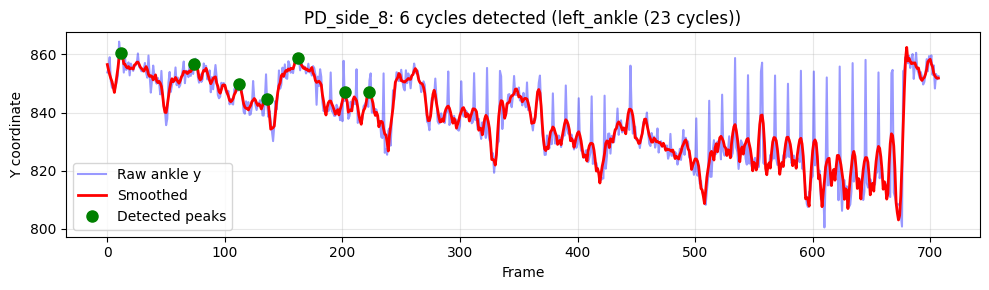

In [6]:
# Visualize cycle detection for the last processed file
# Re-load the last file's data to get y_signal
json_path_viz = JSON_DIR / f"{file_id}.json"
xy_seq_viz = load_alphapose_json(json_path_viz)

# Extract y-signal for left ankle (index 15)
y_signal_viz = xy_seq_viz[:, 15 * 2 + 1]

# Apply smoothing
max_win = len(y_signal_viz) if len(y_signal_viz) % 2 == 1 else len(y_signal_viz) - 1
win = min(9, max_win)
if win < 3:
	win = 3
if win % 2 == 0:
	win += 1

try:
	y_smooth_viz = savgol_filter(y_signal_viz, win, polyorder=2)
except Exception:
	y_smooth_viz = y_signal_viz.copy()

# Plot
plt.figure(figsize=(10, 3))
plt.plot(y_signal_viz, 'b-', alpha=0.4, label='Raw ankle y')
plt.plot(y_smooth_viz, 'r-', linewidth=2, label='Smoothed')
if len(peaks) > 0:
	plt.plot(peaks, y_smooth_viz[peaks], 'go', markersize=8, label='Detected peaks')
plt.title(f"{file_id}: {len(peaks)-1} cycles detected ({used_method})")
plt.xlabel("Frame")
plt.ylabel("Y coordinate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
video_path = "D:/PD/data/outputs/chosen_outputs/walk/NP/NP_front_1/NP_front_1.mp4"
json_path = "D:/PD/PD_latest/dataset/alphapose_walk/NP_front_1.json"

In [8]:
def plot_coco_skeleton(pose_flat, title=""):
    """
    Safely plot COCO-17 skeleton — with diagnostics.
    pose_flat: (34,) array: [x0,y0,x1,y1,...,x16,y16]
    """
    assert len(pose_flat) == 34, f"Expected 34 values, got {len(pose_flat)}"
    
    # Reshape safely
    kp = pose_flat.reshape(17, 2)  # (17, 2)
    
    # Replace NaN with np.nan (for skipping)
    kp = np.where(np.isfinite(kp), kp, np.nan)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Plot joints
    ax.scatter(kp[:, 0], kp[:, 1], c='red', s=100, zorder=5, edgecolors='white', linewidth=2)
    
    # Label joints (only if not NaN)
    for i in range(17):
        x, y = kp[i]
        if not np.isnan(x) and not np.isnan(y):
            ax.text(x + 3, y + 3, f"{i}", fontsize=8, fontweight='bold', zorder=6)
    
    # Draw limbs — skip if either joint is NaN
    for i1, i2 in COCO_EDGES:
        x1, y1 = kp[i1]
        x2, y2 = kp[i2]
        if not (np.isnan(x1) or np.isnan(y1) or np.isnan(x2) or np.isnan(y2)):
            ax.plot([x1, x2], [y1, y2], 'r-', linewidth=2.5, zorder=4)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    
    # AlphaPose outputs image coordinates → y increases downward → invert for plot
    ax.invert_yaxis()
    
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')
    plt.tight_layout()
    return fig, ax

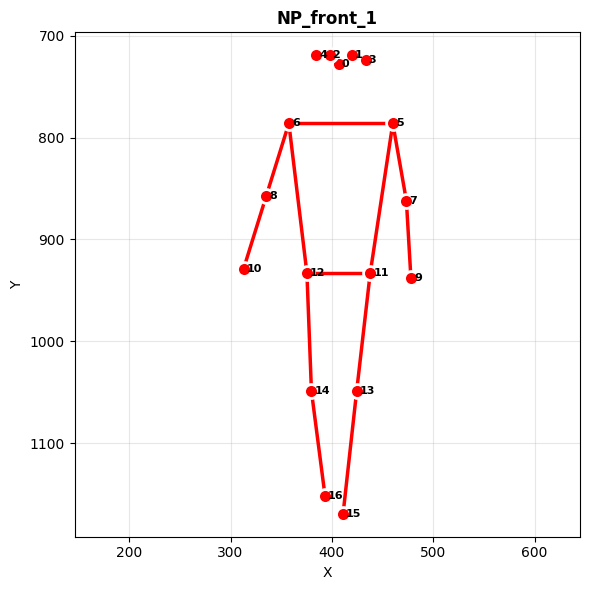

In [9]:
# Use json_path to find & visualize cycle 1's first frame
file_id = Path(json_path).stem
p = CYCLES_DIR / f"{file_id}_cycle_1.json"

# fallback: find first matching cycle file if exact one is missing
if not p.exists():
    matches = sorted(CYCLES_DIR.glob(f"{file_id}_cycle_*.json"))
    if matches:
        p = matches[0]

if not p.exists():
    raise FileNotFoundError(f"No cycle JSON found for {file_id} in {CYCLES_DIR}")

with open(p, 'r', encoding='utf-8') as f:
    obj = json.load(f)

# get xy array (support dict with 'xy' or bare list/array)
if isinstance(obj, dict) and 'xy' in obj:
    arr = np.array(obj['xy'])
else:
    arr = np.array(obj)

# ensure we pick a single 34-length frame
if arr.ndim == 1 and arr.size == 34:
    first_frame = arr
elif arr.ndim == 2 and arr.shape[1] == 34:
    first_frame = arr[0]
else:
    first_frame = arr.flatten()[:34]

# defensive cast and NaN handling
first_frame = np.asarray(first_frame, dtype=float)
first_frame[~np.isfinite(first_frame)] = np.nan

fig, ax = plot_coco_skeleton(first_frame, title=f"{file_id}")
plt.show()


Loaded 93 frames from JSON
   Frames available: [0, 1, 2, 3, 4]...


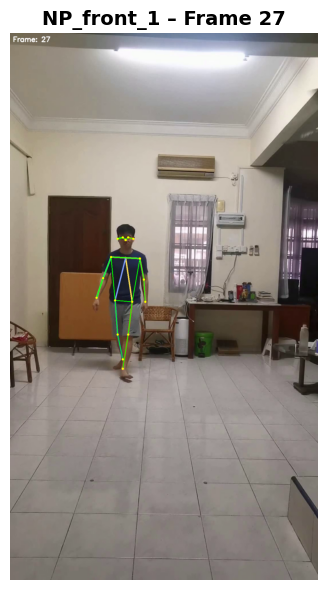

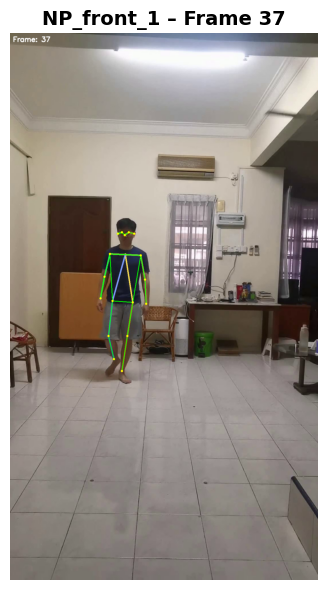

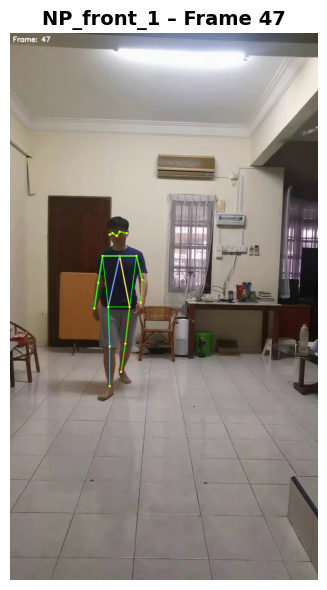

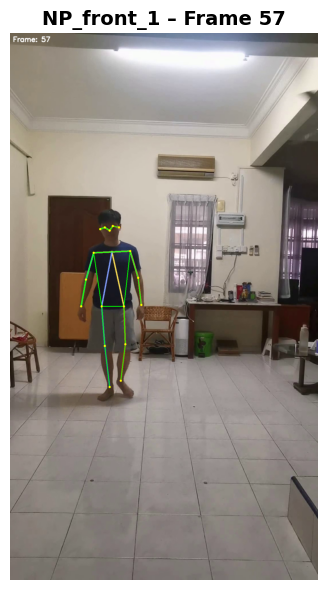

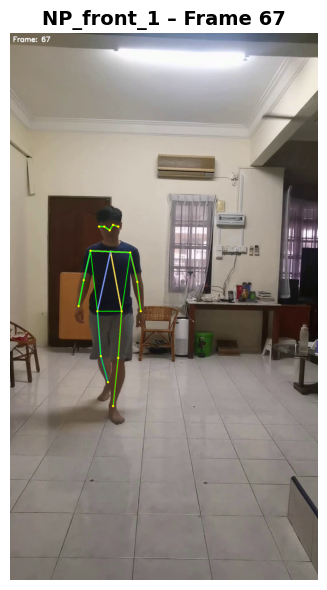

In [10]:
# peaks = np.array([27, 71, 115, 159, 203, 247, 291])  # example
peaks = None  # ← set to None or your array

start_frame = 27
end_frame = 71
step = 10  # frames to skip
confidence_thresh = 0.2  # min keypoint confidence

def parse_frame_number(image_id):
    """Robustly extract frame number from image_id string."""
    if isinstance(image_id, int):
        return image_id
    if not isinstance(image_id, str):
        return None
    # Remove extension
    stem = Path(image_id).stem
    # Find all numbers
    nums = re.findall(r'\d+', stem)
    if not nums:
        return None
    # Heuristic: last number is frame index (e.g., file_frameXYZ → XYZ)
    return int(nums[-1])
def load_keypoints_dict(json_path):
    """Load AlphaPose JSON → {frame_num: (17, 3) array}."""
    with open(json_path) as f:
        data = json.load(f)
    
    kp_dict = {}
    
    # Accept either a list of detections or a dict with 'annotations'
    if isinstance(data, list):
        items = data
    elif isinstance(data, dict) and 'annotations' in data and isinstance(data['annotations'], list):
        items = data['annotations']
    else:
        items = []
    
    for item in items:
        if not isinstance(item, dict):
            continue
        # support several possible keys for filename/id
        image_id = item.get('image_id') or item.get('image') or item.get('file_name')
        fid = parse_frame_number(image_id)
        if fid is None:
            continue
        kp_list = item.get('keypoints')
        if kp_list is None:
            continue
        try:
            kpts = np.array(kp_list).reshape(-1, 3)
            # ensure we have at least 17 keypoints; trim extras
            if kpts.ndim == 2 and kpts.shape[1] == 3 and kpts.shape[0] >= 17:
                kpts = kpts[:17, :]
                kp_dict[fid] = kpts
        except Exception:
            continue
    return kp_dict

def draw_skeleton(frame, keypoints, edges, 
                  joint_color=(0, 255, 255), limb_color=(0, 255, 0),
                  thickness=2, radius=4, conf_thresh=0.2):
    """Draw COCO skeleton on OpenCV BGR frame."""
    h, w = frame.shape[:2]
    # Draw limbs
    for i1, i2 in edges:
        x1, y1, s1 = keypoints[i1]
        x2, y2, s2 = keypoints[i2]
        if s1 >= conf_thresh and s2 >= conf_thresh:
            pt1 = (int(np.clip(x1, 0, w-1)), int(np.clip(y1, 0, h-1)))
            pt2 = (int(np.clip(x2, 0, w-1)), int(np.clip(y2, 0, h-1)))
            cv2.line(frame, pt1, pt2, limb_color, thickness)
            cv2.circle(frame, pt1, radius, joint_color, -1)
            cv2.circle(frame, pt2, radius, joint_color, -1)
    return frame

def annotate_frame(frame, frame_idx, is_peak=False):
    """Add frame number and optional peak marker."""
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(frame, f"Frame: {frame_idx}", (10, 30), 
                font, 0.8, (255, 255, 255), 2, cv2.LINE_AA)
    if is_peak:
        cv2.putText(frame, "PEAK", (10, 60), font, 0.8, (0, 0, 255), 2, cv2.LINE_AA)
        cv2.rectangle(frame, (5, 5), (frame.shape[1]-5, frame.shape[0]-5), (0, 0, 255), 3)
    return frame

# ──────────────── MAIN ────────────────

# Load data
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video: {video_path}")

kp_dict = load_keypoints_dict(json_path)
if not kp_dict:
    raise ValueError("No keypoints loaded from JSON")

print(f"Loaded {len(kp_dict)} frames from JSON")
print(f"   Frames available: {sorted(kp_dict.keys())[:5]}...")

# Set frame range
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
if end_frame is None:
    end_frame = total_frames - 1
frame_range = range(start_frame, min(end_frame + 1, total_frames), step)

# Plot frames
for fid in frame_range:
    # Read frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, fid)
    ret, frame = cap.read()
    if not ret:
        print(f"Failed to read frame {fid}")
        continue
    
    # Get keypoints (fallback: nearest frame if missing)
    if fid in kp_dict:
        kpts = kp_dict[fid]
    else:
        # Find nearest available frame
        available = np.array(list(kp_dict.keys()))
        if len(available) == 0:
            print(f"No keypoints for any frame")
            continue
        nearest = available[np.argmin(np.abs(available - fid))]
        kpts = kp_dict[nearest]
        print(f"Frame {fid} missing → using nearest: {nearest}")
    
    # Draw skeleton
    frame_vis = draw_skeleton(
        frame.copy(), 
        kpts, 
        COCO_EDGES,
        conf_thresh=confidence_thresh
    )
    
    # Annotate
    is_peak = peaks is not None and fid in peaks
    frame_vis = annotate_frame(frame_vis, fid, is_peak=is_peak)
    
    # Convert BGR → RGB for matplotlib
    rgb = cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.imshow(rgb)
    plt.title(f"{Path(video_path).stem} – Frame {fid}", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

cap.release()